In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import numpy as np

# 设置绘图风格和中文字体
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']  
plt.rcParams['axes.unicode_minus'] = False

# 连接数据库
con = sqlite3.connect('olist.db')

In [4]:
# ============================ 深入探究：用户分层及相关探究 =========================

# ------------------- 数据读取与清洗 ---------------------------

# 读取数据
sql_query = """ 
SELECT c.customer_unique_id,
       MAX(o.order_purchase_timestamp) AS last_purchase_time,
       COUNT(DISTINCT o.order_id) AS frequency,
       SUM(oi.price) AS monetary
FROM orders o
INNER JOIN customers c ON o.customer_id = c.customer_id
INNER JOIN order_items oi ON o.order_id = oi.order_id
WHERE o.order_status = 'delivered'
GROUP BY c.customer_unique_id
"""

df_rfm_raw = pd.read_sql_query(sql_query, con)

# 处理重复值
df_rfm_raw.drop_duplicates(inplace=True)

# 转换时间格式
df_rfm_raw['last_purchase_time'] = pd.to_datetime(df_rfm_raw['last_purchase_time'])

# 处理业务噪音
dp_one = df_rfm_raw[df_rfm_raw['last_purchase_time'] != 2016]

In [5]:
# ----------------------- 用户分层 -------------------------------

# 以数据集中最后一笔订单的时间 + 1天 作为“今天”（分析基准点）
today = df_rfm_raw['last_purchase_time'].max() + pd.Timedelta(days=1)

# 计算 Recency (距离今天的天数)
df_rfm_raw['recency'] = (today - df_rfm_raw['last_purchase_time']).dt.days


# 1. R值打分：时间越近（天数越小）分数越高 (5分制)
df_rfm_raw['R_score'] = pd.qcut(df_rfm_raw['recency'], q=5, labels=[5, 4, 3, 2, 1]).astype(int)

# 2. F值打分：由于97%的用户只买过1次，采用自定义规则
# 1次 -> 1分； 2次 -> 3分； 3次及以上 -> 5分
def get_f_score(f):
    if f == 1:
        return 1
    elif f == 2:
        return 3
    else:
        return 5
df_rfm_raw['F_score'] = df_rfm_raw['frequency'].apply(get_f_score)

# 3. M值打分：消费金额越高，分数越高 (5分制)
df_rfm_raw['M_score'] = pd.qcut(df_rfm_raw['monetary'], q=5, labels=[1, 2, 3, 4, 5]).astype(int)


# 计算各项得分的平均值作为高低的判定标准
r_mean = df_rfm_raw['R_score'].mean()
f_mean = df_rfm_raw['F_score'].mean()
m_mean = df_rfm_raw['M_score'].mean()

# 判断是否高于平均值
df_rfm_raw['R_high'] = df_rfm_raw['R_score'] >= r_mean
df_rfm_raw['F_high'] = df_rfm_raw['F_score'] >= f_mean
df_rfm_raw['M_high'] = df_rfm_raw['M_score'] >= m_mean

# 定义 8 大客户细分规则
def get_segment(row):
    r, f, m = row['R_high'], row['F_high'], row['M_high']
    if r and f and m:
        return '重要价值客户'  # 最近买过、频次高、花钱多
    elif not r and f and m:
        return '重要保持客户'  # 频次高花钱多，但最近没来（有流失风险）
    elif r and not f and m:
        return '重要发展客户'  # 最近买过、花钱多，但频次低（新大客户）
    elif not r and not f and m:
        return '重要挽留客户'  # 花钱多，但最近没来且频次低
    elif r and f and not m:
        return '一般价值客户'  # 最近常来，但花钱少
    elif not r and f and not m:
        return '一般保持客户'  # 频次高但花钱少，最近没来
    elif r and not f and not m:
        return '一般发展客户(新客户)' # 最近刚来，花钱少，频次低
    else:
        return '一般挽留客户(流失客户)' # 彻底流失的低价值用户

df_rfm_raw['segment'] = df_rfm_raw.apply(get_segment, axis=1)

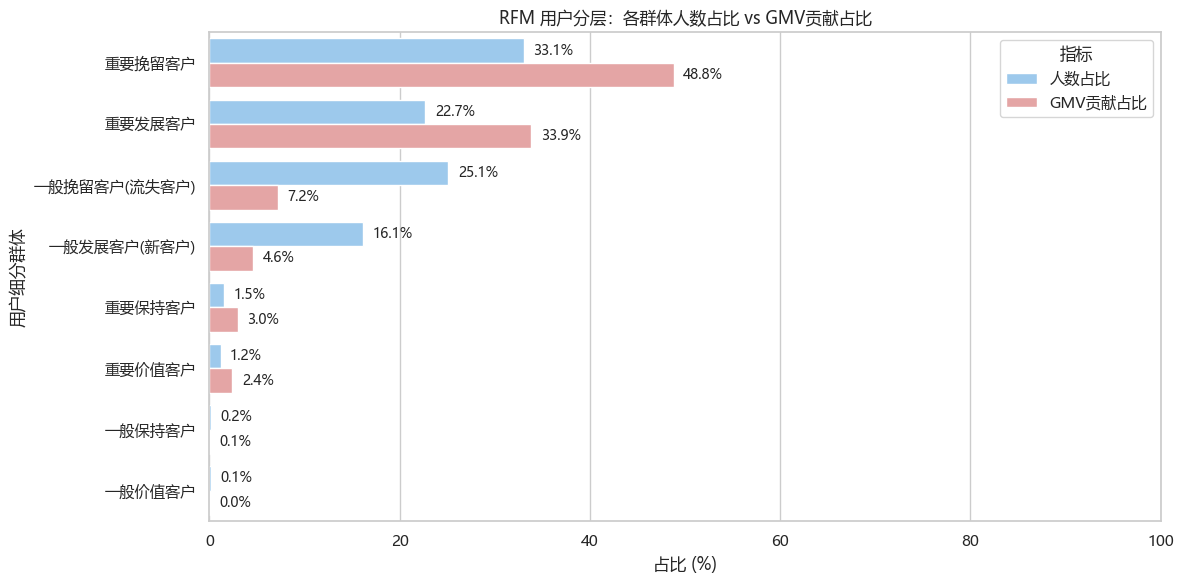

In [6]:
# ------------------- 用户分层可视化 ------------------------------

# 再次设置字体，防止失效
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']  
plt.rcParams['axes.unicode_minus'] = False

# 准备数据
segment_summary = df_rfm_raw.groupby('segment').agg(
    user_count=('customer_unique_id', 'count'),
    total_gmv=('monetary', 'sum')
).reset_index()

# 计算占比
segment_summary['user_pct'] = segment_summary['user_count'] / segment_summary['user_count'].sum() * 100
segment_summary['gmv_pct'] = segment_summary['total_gmv'] / segment_summary['total_gmv'].sum() * 100
segment_summary = segment_summary.sort_values(by='gmv_pct', ascending=False)

# 绘图

plt.figure(figsize=(12, 6))

# 将数据整理为适合 seaborn 绘制的格式
plot_data = pd.melt(
    segment_summary, 
    id_vars=['segment'], 
    value_vars=['user_pct', 'gmv_pct'],
    var_name='指标类型', 
    value_name='占比(%)'
)
plot_data['指标类型'] = plot_data['指标类型'].map({'user_pct': '人数占比', 'gmv_pct': 'GMV贡献占比'})

# 绘制分组柱状图
ax = sns.barplot(
    x='占比(%)', 
    y='segment', 
    hue='指标类型', 
    data=plot_data, 
    palette=['#90caf9', '#ef9a9a'] # 蓝色代表人数，红色代表金额
)

# 在柱状图上标注具体数值
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.text(
            width + 1, 
            p.get_y() + p.get_height()/2, 
            f'{width:.1f}%', 
            ha='left', 
            va='center', 
            fontsize=10, 
        )

plt.title('RFM 用户分层：各群体人数占比 vs GMV贡献占比')
plt.xlabel('占比 (%)')
plt.ylabel('用户细分群体')
plt.xlim(0, 100)
plt.legend(title='指标')
plt.tight_layout()
plt.show()


# 通过用户分层，可以发现客户群体中超过50%是重要挽留客户和重要发展客户，还有25%的流失客户，可见平台的客户流失非常严重
# 重要挽留顾客和重要发展顾客贡献了超过80%的营业额，说明平台的营收结构十分脆弱，缺乏稳定的销售点
# 以上两点说明，虽然数据上平台每月的的订单数和销售额呈现出递增趋势，但这更像是互联网红利下的虚假繁荣
# 平台需要抓住时代红利，加大对基础设施、用户需求方面的投入，实现对用户的深度绑定，以短期利益换取长远的未来

In [7]:
# ====================================== 深入探究：物流分析 ====================================

# ------------------- 准备数据 -----------------------

# 1、读取数据
logistics_expanded_sql = """
SELECT 
    o.order_id,
    o.order_status,
    c.customer_unique_id,
    c.customer_state,
    o.order_purchase_timestamp,
    o.order_delivered_carrier_date,
    o.order_delivered_customer_date,
    o.order_estimated_delivery_date,
    oi.price,
    oi.freight_value,
    r.review_score
FROM orders o
INNER JOIN customers c ON o.customer_id = c.customer_id
INNER JOIN order_items oi ON o.order_id = oi.order_id
LEFT JOIN order_reviews r ON o.order_id = r.order_id
WHERE o.order_delivered_carrier_date IS NOT NULL  -- 核心修改：只要发了货的都算
"""

df_logistics = pd.read_sql_query(logistics_expanded_sql, con)

# 处理重复值
df_logistics.drop_duplicates(inplace=True)

# 转换时间格式
date_cols = ['order_purchase_timestamp', 'order_delivered_carrier_date', 
             'order_delivered_customer_date', 'order_estimated_delivery_date']
for col in date_cols:
    df_logistics[col] = pd.to_datetime(df_logistics[col])

# 过滤 2016 年噪音
df_logistics = df_logistics[df_logistics['order_purchase_timestamp'].dt.year != 2016]

# 定义“今天”作为分析基准点（数据集中最后一笔订单时间）
today = df_logistics['order_purchase_timestamp'].max()

# ==============================================================================
# 2. 核心计算：兼容“已送达”与“在途/滞留”的算法
# ==============================================================================

# 2.1 商家处理时长（所有订单都可以算，因为都发货了）
df_logistics['seller_days'] = (df_logistics['order_delivered_carrier_date'] - df_logistics['order_purchase_timestamp']).dt.total_seconds() / 86400

# 2.2 物流运输时长（分类讨论）
# - 如果已送达：用 实际送达时间 - 发货时间
# - 如果在途中：用 今天 - 发货时间（代表已经漂流了多少天）
df_logistics['carrier_days'] = np.where(
    df_logistics['order_status'] == 'delivered',
    (df_logistics['order_delivered_customer_date'] - df_logistics['order_delivered_carrier_date']).dt.total_seconds() / 86400,
    (today - df_logistics['order_delivered_carrier_date']).dt.total_seconds() / 86400
)

# 2.3 总配送时长
df_logistics['total_delivery_days'] = df_logistics['seller_days'] + df_logistics['carrier_days']

# 2.4 承诺偏差天数与超期判定（SLA）
# - 如果已送达：实际送达 - 预计送达
# - 如果在途中：今天 - 预计送达
df_logistics['sla_delta'] = np.where(
    df_logistics['order_status'] == 'delivered',
    (df_logistics['order_delivered_customer_date'] - df_logistics['order_estimated_delivery_date']).dt.total_seconds() / 86400,
    (today - df_logistics['order_estimated_delivery_date']).dt.total_seconds() / 86400
)

# 判定是否超期（偏差 > 0 即为超期）
df_logistics['is_overdue'] = df_logistics['sla_delta'] > 0

# 运费率
df_logistics['freight_ratio'] = df_logistics['freight_value'] / df_logistics['price']

# ==============================================================================
# 3. 关联 RFM 用户分层数据
# ==============================================================================
df_merged = pd.merge(
    df_logistics, 
    df_rfm_raw[['customer_unique_id', 'segment']], 
    on='customer_unique_id', 
    how='inner'
)

print(f"【新数据集准备完毕】")
print(f"总样本量: {len(df_merged)}")
print(f"其中已送达(delivered)数量: {len(df_merged[df_merged['order_status']=='delivered'])}")
print(f"其中在途/滞留(shipped)数量: {len(df_merged[df_merged['order_status']=='shipped'])}")
print(f"其中发货后取消(canceled)数量: {len(df_merged[df_merged['order_status']=='canceled'])}")

【新数据集准备完毕】
总样本量: 99359
其中已送达(delivered)数量: 99291
其中在途/滞留(shipped)数量: 63
其中发货后取消(canceled)数量: 5


C:\Users\dengjiaxin\AppData\Local\Temp\ipykernel_21324\2029365711.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


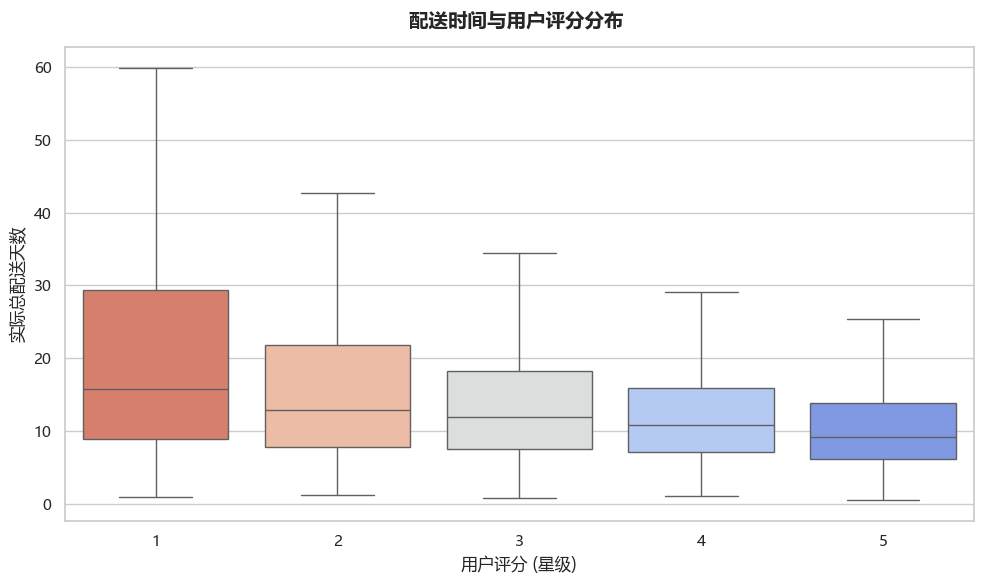

In [8]:
# -------------------- 配送时长与用户评分的关系 ----------------------

plt.figure(figsize=(10, 6))

# 绘制箱线图，限制 y 轴在 60 天以内以排除极端异常值，看得更清晰
sns.boxplot(
    x='review_score', 
    y='total_delivery_days', 
    data=df_merged, 
    palette='coolwarm_r',
    showfliers=False # 不显示异常值点，使箱体更美观
)

plt.title('配送时间与用户评分分布 ', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('用户评分 (星级)', fontsize=12)
plt.ylabel('实际总配送天数', fontsize=12)
plt.tight_layout()
plt.show()


# 从下面的箱型图可以看出，1星评价订单的平均配送时间接近20天，5星评价订单的平均配送时间只有10天，二者相差巨大
# 可见，改善物流是提升服务品质的重要部分，恶劣的物流服务很可能对用户的消费意愿造成严重打击

C:\Users\dengjiaxin\AppData\Local\Temp\ipykernel_21324\3045047555.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


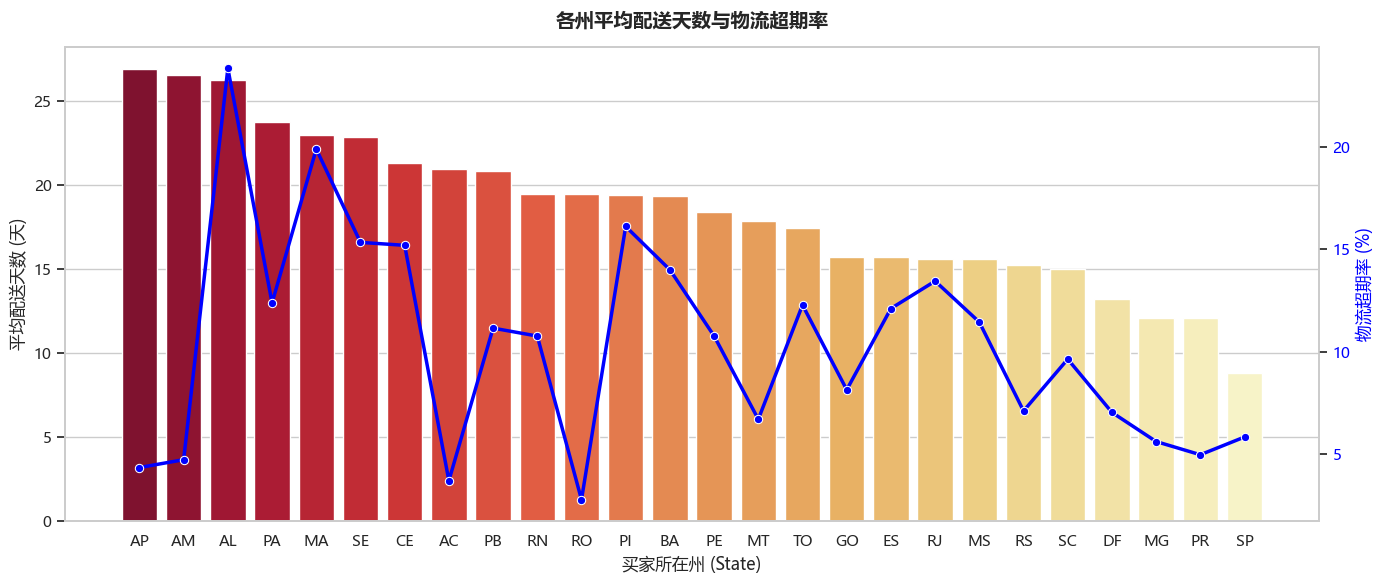

In [9]:
#计算各州的平均配送天数和超期率
state_logistics = df_merged.groupby('customer_state').agg(
    avg_delivery=('total_delivery_days', 'mean'),
    overdue_rate=('is_overdue', 'mean'),
    order_count=('order_id', 'count')
).reset_index()

# 过滤掉订单量极少的州（比如少于50单的），确保数据有代表性
state_logistics = state_logistics[state_logistics['order_count'] > 50]
state_logistics = state_logistics.sort_values(by='avg_delivery', ascending=False)

# 开始画图
fig, ax1 = plt.subplots(figsize=(14, 6))

# 1. 绘制柱状图（平均配送天数）
sns.barplot(
    x='customer_state', 
    y='avg_delivery', 
    data=state_logistics, 
    ax=ax1, 
    palette='YlOrRd_r'
)
ax1.set_title('各州平均配送天数与物流超期率', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('买家所在州 (State)', fontsize=12)
ax1.set_ylabel('平均配送天数 (天)', fontsize=12)

# 2. 绘制折线图（超期率）- 使用双 Y 轴
ax2 = ax1.twinx()
sns.lineplot(
    x='customer_state', 
    y=state_logistics['overdue_rate'] * 100, # 转为百分比
    data=state_logistics, 
    ax=ax2, 
    color='blue', 
    marker='o', 
    linewidth=2.5,
    sort=False
)
ax2.set_ylabel('物流超期率 (%)', fontsize=12, color='blue')
ax2.tick_params(axis='y', labelcolor='blue')
ax2.grid(False) # 关闭折线图的网格线，避免重叠

plt.tight_layout()
plt.show()


# 受巴西疆域辽阔的影响，加上跨州交易占据了60%的订单，各州的平均配送天数普遍较高，AP、AM等比较偏远的州的平均配送天数甚至逼近一个月
# 而且，大多数州的超期率都在10%以上，可见物流质量比较低下，其中AL的超期率甚至超过了20%
# 针对这类情况，简单的增效无法从根本上改变受限于地理的物流困境，建议开发本地仓储模式，将分散全国各地的货物运输到离消费者较近的地区，进行集中处理

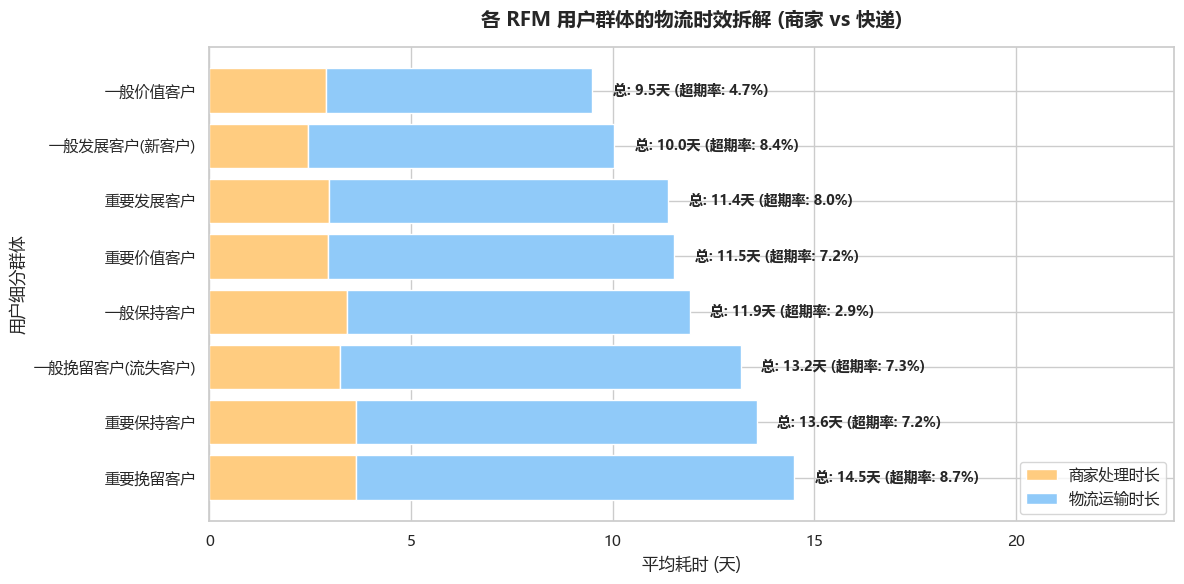

In [10]:
# 计算每个 RFM 群体的物流表现
segment_logistics = df_merged.groupby('segment').agg(
    avg_seller_days=('seller_days', 'mean'),
    avg_carrier_days=('carrier_days', 'mean'),
    avg_total_days=('total_delivery_days', 'mean'),
    overdue_rate=('is_overdue', 'mean')
).reset_index().sort_values(by='avg_total_days', ascending=False)

# 绘制堆叠条形图（商家处理时长 + 物流运输时长）
plt.figure(figsize=(12, 6))

# 准备堆叠图数据
r_labels = segment_logistics['segment'].tolist()
seller_means = segment_logistics['avg_seller_days'].tolist()
carrier_means = segment_logistics['avg_carrier_days'].tolist()

# 画商家处理时长
bars1 = plt.barh(r_labels, seller_means, label='商家处理时长', color='#ffcc80')
# 画物流运输时长（叠在商家处理时长后面）
bars2 = plt.barh(r_labels, carrier_means, left=seller_means, label='物流运输时长', color='#90caf9')

# 标注总天数和超期率
for i, row in enumerate(segment_logistics.itertuples()):
    total_days = row.avg_total_days
    overdue_pct = row.overdue_rate * 100
    plt.text(
        total_days + 0.5, 
        i, 
        f"总: {total_days:.1f}天 (超期率: {overdue_pct:.1f}%)", 
        va='center', 
        fontweight='bold', 
        fontsize=10
    )

plt.title('各 RFM 用户群体的物流时效拆解 (商家 vs 快递)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('平均耗时 (天)', fontsize=12)
plt.ylabel('用户细分群体', fontsize=12)
plt.legend(loc='lower right')
plt.xlim(0, max(seller_means + carrier_means) * 2.2) # 留出右侧标注空间
plt.tight_layout()
plt.show()

# 各RFM用户群体中，重要挽留顾客是平台最重要的GMV贡献群体，但是物流时效却是所有群体里最低的，如果不能推出相关措施，很可能会加剧顾客流失
# 商家处理时长也是导致超期率的一大因素，商家处理时长普遍在2-4天左右，应将其纳入改善物流的计划内